## 📌 Notice: About This Performance Analysis

This performance analysis is based on the following assumptions and design decisions:

- All order creation, execution, and matching logic has already been processed inside the backtesting engine  
  (`gateway → order_manager → orderbook`).

- The dataset `engine_events.csv` represents the full chronological stream of strategy signals and order events.

- The dataset `engine_trades.csv` contains only the trades that were successfully matched by the internal orderbook.

- Because the system uses a single internal orderbook, it is assumed that **all submitted orders are fully matched**,  
  with no modeling of partial fills, slippage, latency, or market microstructure effects.

- Therefore, the equity curve and performance metrics in this notebook are computed strictly based on executed trades,  
  under the assumption that all generated orders eventually result in a fill.

In short, this notebook provides a **transaction-driven performance evaluation**,  
reflecting the engine's matched-trade outcomes rather than real-market execution behavior.


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Price data
price = pd.read_csv("data/AAPL_1m.csv")
price["timestamp"] = pd.to_datetime(price["timestamp"])
price = price.set_index("timestamp").sort_index()

# Events (signals)
events = pd.read_csv("result/engine_events.csv")
events["timestamp"] = pd.to_datetime(events["timestamp"])
events = events.sort_values("timestamp").reset_index(drop=True)

price.head(), events.head()


(                            close    high     low    open  volume symbol
 timestamp                                                               
 2025-11-18 09:00:00+00:00  267.54  267.88  267.50  267.68       0   AAPL
 2025-11-18 09:02:00+00:00  267.51  267.62  267.51  267.62       0   AAPL
 2025-11-18 09:03:00+00:00  267.69  267.69  267.62  267.62       0   AAPL
 2025-11-18 09:04:00+00:00  267.86  267.90  267.80  267.80       0   AAPL
 2025-11-18 09:05:00+00:00  267.58  267.98  267.58  267.98       0   AAPL,
                   timestamp  \
 0 2025-11-18 09:00:00+00:00   
 1 2025-11-18 09:02:00+00:00   
 2 2025-11-18 09:03:00+00:00   
 3 2025-11-18 09:04:00+00:00   
 4 2025-11-18 09:05:00+00:00   
 
                                               signal order_id trades  
 0  Signal(ts=2025-11-18 09:00:00+00:00, action=HO...      NaN     []  
 1  Signal(ts=2025-11-18 09:02:00+00:00, action=HO...      NaN     []  
 2  Signal(ts=2025-11-18 09:03:00+00:00, action=HO...      NaN     []  

In [69]:
def extract_signal(text):
    if "BUY" in text:
        return "BUY"
    elif "SELL" in text:
        return "SELL"
    else:
        return "HOLD"

events["signal_action"] = events["signal"].apply(extract_signal)
events.tail()


,timestamp,signal,order_id,trades,signal_action
912,2025-11-19 00:55:00+00:00,"Signal(ts=2025-11-19 00:55:00+00:00, action=BU...",f51c789d-bc63-42a6-b515-fccfbca74cd1,"[{'price': 266.83, 'qty': 1, 'buy_id': 'f51c78...",BUY
913,2025-11-19 00:56:00+00:00,"Signal(ts=2025-11-19 00:56:00+00:00, action=BU...",5978e1f0-652e-4d94-81a7-cdaa47b410b9,"[{'price': 266.84, 'qty': 1, 'buy_id': '5978e1...",BUY
914,2025-11-19 00:57:00+00:00,"Signal(ts=2025-11-19 00:57:00+00:00, action=BU...",c5ddacfd-2dce-488b-aeba-c55aa42d848f,"[{'price': 266.86, 'qty': 1, 'buy_id': 'c5ddac...",BUY
915,2025-11-19 00:58:00+00:00,"Signal(ts=2025-11-19 00:58:00+00:00, action=BU...",4f6b95a1-1e39-4ea2-808e-923d14cc7fea,"[{'price': 266.9, 'qty': 1, 'buy_id': '4f6b95a...",BUY
916,2025-11-19 00:59:00+00:00,"Signal(ts=2025-11-19 00:59:00+00:00, action=BU...",91d2c11e-64f9-4863-bca1-f8bdf125bd63,"[{'price': 266.9, 'qty': 1, 'buy_id': '91d2c11...",BUY


In [70]:
events["position"] = 0
pos = 0

for i in range(len(events)):
    action = events.loc[i, "signal_action"]
    qty = 1 

    if action == "BUY":
        pos += qty
    elif action == "SELL":
        pos -= qty
    
    events.loc[i, "position"] = pos

events[["timestamp", "signal_action", "position"]]


,timestamp,signal_action,position
0,2025-11-18 09:00:00+00:00,HOLD,0
1,2025-11-18 09:02:00+00:00,HOLD,0
2,2025-11-18 09:03:00+00:00,HOLD,0
3,2025-11-18 09:04:00+00:00,HOLD,0
4,2025-11-18 09:05:00+00:00,HOLD,0
...,...,...,...
912,2025-11-19 00:55:00+00:00,BUY,-152
913,2025-11-19 00:56:00+00:00,BUY,-151
914,2025-11-19 00:57:00+00:00,BUY,-150
915,2025-11-19 00:58:00+00:00,BUY,-149


In [ ]:
# vlookup-price & event 
events = events.set_index("timestamp")
events["price"] = price["close"].reindex(events.index, method='ffill')

events.tail()


,signal,order_id,trades,signal_action,position,price
timestamp,,,,,,
2025-11-19 00:55:00+00:00,"Signal(ts=2025-11-19 00:55:00+00:00, action=BU...",f51c789d-bc63-42a6-b515-fccfbca74cd1,"[{'price': 266.83, 'qty': 1, 'buy_id': 'f51c78...",BUY,-152,267.0000
2025-11-19 00:56:00+00:00,"Signal(ts=2025-11-19 00:56:00+00:00, action=BU...",5978e1f0-652e-4d94-81a7-cdaa47b410b9,"[{'price': 266.84, 'qty': 1, 'buy_id': '5978e1...",BUY,-151,267.0087
2025-11-19 00:57:00+00:00,"Signal(ts=2025-11-19 00:57:00+00:00, action=BU...",c5ddacfd-2dce-488b-aeba-c55aa42d848f,"[{'price': 266.86, 'qty': 1, 'buy_id': 'c5ddac...",BUY,-150,267.1000
2025-11-19 00:58:00+00:00,"Signal(ts=2025-11-19 00:58:00+00:00, action=BU...",4f6b95a1-1e39-4ea2-808e-923d14cc7fea,"[{'price': 266.9, 'qty': 1, 'buy_id': '4f6b95a...",BUY,-149,267.1000
2025-11-19 00:59:00+00:00,"Signal(ts=2025-11-19 00:59:00+00:00, action=BU...",91d2c11e-64f9-4863-bca1-f8bdf125bd63,"[{'price': 266.9, 'qty': 1, 'buy_id': '91d2c11...",BUY,-148,267.0100


In [66]:
initial_capital = 100000
cash = initial_capital

equity_list = []

for ts, row in events.iterrows():
    price_now = row["price"]
    pos = row["position"]

    equity = cash + pos * price_now
    equity_list.append([ts, equity])

equity_df = pd.DataFrame(equity_list, columns=["timestamp", "equity"])
equity_df = equity_df.set_index("timestamp")
equity_df.tail()


,equity
timestamp,
2025-11-19 00:55:00+00:00,100000.0
2025-11-19 00:56:00+00:00,100000.0
2025-11-19 00:57:00+00:00,100000.0
2025-11-19 00:58:00+00:00,100000.0
2025-11-19 00:59:00+00:00,100000.0


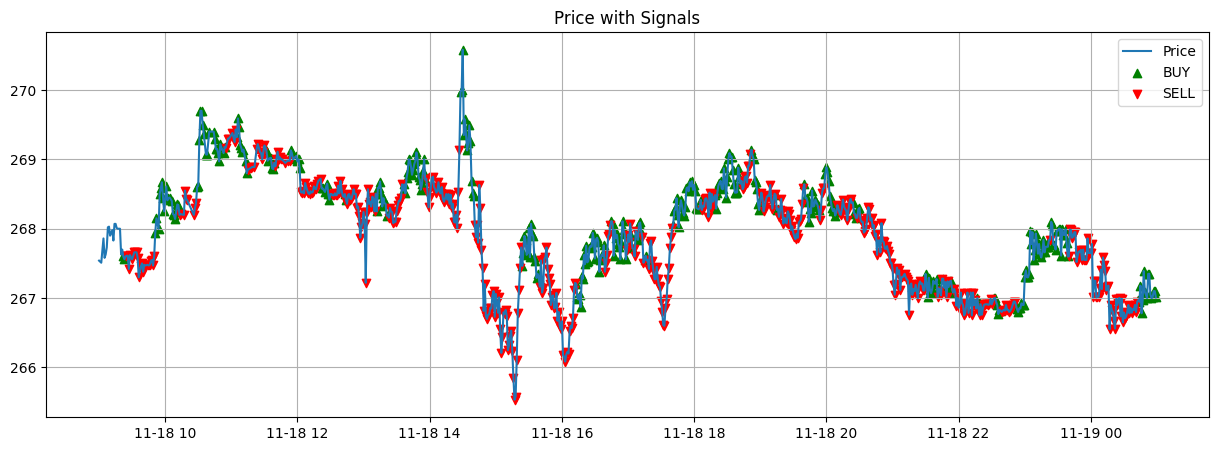

In [56]:
plt.figure(figsize=(15,5))
plt.plot(price.index, price["close"], label="Price")

# Signal markers
buy_ts = events[events["signal_action"]=="BUY"].index
sell_ts = events[events["signal_action"]=="SELL"].index

plt.scatter(buy_ts, price.loc[buy_ts]["close"], color='green', marker='^', label="BUY")
plt.scatter(sell_ts, price.loc[sell_ts]["close"], color='red', marker='v', label="SELL")

plt.legend()
plt.title("Price with Signals")
plt.grid(True)
plt.show()


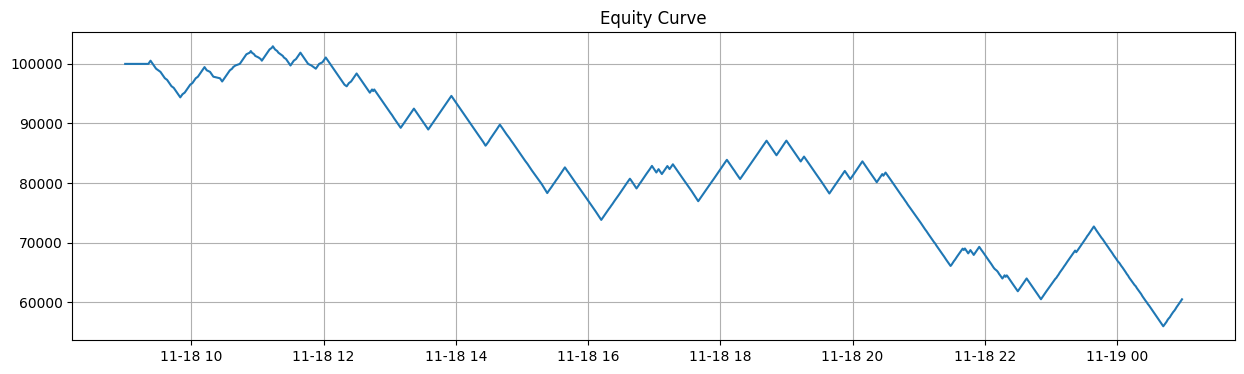

In [58]:
plt.figure(figsize=(15,4))
plt.plot(equity_df.index, equity_df["equity"])
plt.title("Equity Curve")
plt.grid(True)
plt.show()


In [60]:
# Performance Summary
import pandas as pd

summary = pd.DataFrame({
    "Sharpe Ratio": [round(sharpe, 3)],
    "Max Drawdown": [round(max_dd, 3)],
    "Total Return": [round(total_return, 3)]
})

summary.index = ["Strategy Performance"]
summary


,Sharpe Ratio,Max Drawdown,Total Return
Strategy Performance,-51.132,-0.457,-0.395
